# Sensitivity Analysis Summary
Summarise the Pitman-Yor / tie-penalty sensitivity runs from `bench_py_tiepen.py`.

**Experiment 1** — Pitman-Yor parameter sweep (tie_penalty = 0.5)  
**Experiment 2** — Tie-penalty sweep (no PY prior, p = 0.1 .. 0.9)

In [13]:
import json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Point this at the sensitivity run folder ─────────────────────────────────
SENS_DIR = Path("f1_data/runs/sensitivity_20260411_221806")
assert SENS_DIR.exists(), f"Run folder not found: {SENS_DIR}"

# Discover completed configs
config_dirs = sorted([d for d in SENS_DIR.iterdir() if d.is_dir() and (d / "summary.json").exists()])
print(f"Found {len(config_dirs)} completed configs in {SENS_DIR.name}")
for d in config_dirs:
    print(f"  {d.name}")

Found 21 completed configs in sensitivity_20260411_221806
  noPY_p0.1
  noPY_p0.2
  noPY_p0.3
  noPY_p0.4
  noPY_p0.5
  noPY_p0.6
  noPY_p0.7
  noPY_p0.8
  noPY_p0.9
  PY_g0.5_d0.0_p0.5
  PY_g0.5_d0.25_p0.5
  PY_g0.5_d0.5_p0.5
  PY_g0.5_d0.75_p0.5
  PY_g1.0_d0.0_p0.5
  PY_g1.0_d0.25_p0.5
  PY_g1.0_d0.5_p0.5
  PY_g1.0_d0.75_p0.5
  PY_g2.0_d0.0_p0.5
  PY_g2.0_d0.25_p0.5
  PY_g2.0_d0.5_p0.5
  PY_g2.0_d0.75_p0.5


In [14]:
# ── Load all summaries + samples ──────────────────────────────────────────────
records = []

for d in config_dirs:
    with open(d / "summary.json") as f:
        s = json.load(f)

    # Load samples to get per-iteration block counts (K)
    with open(d / "samples.pkl", "rb") as f:
        samples = pickle.load(f)

    # K is [T_saved][C] — number of blocks per cluster per saved iteration
    K_arr = np.array(samples.K)  # shape (T_saved, C)

    # z_samples to find active clusters per iteration
    z_arr = np.array(samples.z_samples)  # (T_saved, N)

    # Per-iteration: for each active cluster, gather block counts
    T_saved, C_total = K_arr.shape
    all_K_active = []           # flat list of block counts for active clusters across all iterations
    n_active_per_iter = []      # number of active clusters per iteration
    mean_K_per_iter = []        # mean blocks across active clusters per iteration
    max_K_per_iter = []
    min_K_per_iter = []

    for t in range(T_saved):
        active_c = set(z_arr[t])
        k_active = [K_arr[t, c] for c in active_c if K_arr[t, c] > 0]
        all_K_active.extend(k_active)
        n_active_per_iter.append(len(k_active))
        if k_active:
            mean_K_per_iter.append(np.mean(k_active))
            max_K_per_iter.append(np.max(k_active))
            min_K_per_iter.append(np.min(k_active))
        else:
            mean_K_per_iter.append(np.nan)
            max_K_per_iter.append(np.nan)
            min_K_per_iter.append(np.nan)

    # Theta traces (post burn-in)
    theta_arr = np.array(samples.theta_samples) if samples.theta_samples else None

    rec = {
        "label":          s["label"],
        "gamma":          s["gamma"],
        "delta":          s["delta"],
        "tie_penalty":    s["tie_penalty"],
        "use_py_prior":   s["use_py_prior"],
        "elapsed_s":      s["elapsed_s"],
        # Active clusters
        "n_active_final":     s["n_active_clusters"],
        "n_active_mean":      np.mean(n_active_per_iter),
        "n_active_median":    np.median(n_active_per_iter),
        # Block counts (across all active clusters, all post-burnin iterations)
        "K_mean":         np.mean(all_K_active),
        "K_median":       np.median(all_K_active),
        "K_std":          np.std(all_K_active),
        "K_min":          np.min(all_K_active),
        "K_max":          np.max(all_K_active),
        "K_q25":          np.percentile(all_K_active, 25),
        "K_q75":          np.percentile(all_K_active, 75),
        # Per-iteration averages (mean of the per-iter mean)
        "K_iter_mean_avg":    np.nanmean(mean_K_per_iter),
        "K_iter_max_avg":     np.nanmean(max_K_per_iter),
        "K_iter_min_avg":     np.nanmean(min_K_per_iter),
        # Theta
        "theta_mean":     float(np.nanmean(theta_arr)) if theta_arr is not None else np.nan,
    }
    # Log-p (skip if -Infinity)
    logp = s.get("mean_logp_post_burnin", None)
    rec["mean_logp"] = logp if logp is not None and np.isfinite(logp) else np.nan

    records.append(rec)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} configs.")
df[["label", "gamma", "delta", "tie_penalty", "use_py_prior",
    "n_active_final", "K_mean", "K_median", "K_min", "K_max", "elapsed_s"]]

Loaded 21 configs.


,label,gamma,delta,tie_penalty,use_py_prior,n_active_final,K_mean,K_median,K_min,K_max,elapsed_s
0,noPY_p0.1,1.0,0.50,0.1,False,14,31.008457,29.0,18,51,523.8
1,noPY_p0.2,1.0,0.50,0.2,False,12,36.721883,37.5,18,59,962.7
2,noPY_p0.3,1.0,0.50,0.3,False,12,41.208817,38.0,21,76,546.8
3,noPY_p0.4,1.0,0.50,0.4,False,13,43.236708,38.0,20,77,573.5
4,noPY_p0.5,1.0,0.50,0.5,False,10,52.349820,47.0,27,77,1245.3
5,noPY_p0.6,1.0,0.50,0.6,False,11,49.632873,44.0,18,77,538.2
6,noPY_p0.7,1.0,0.50,0.7,False,12,47.628400,42.0,24,77,542.7
7,noPY_p0.8,1.0,0.50,0.8,False,11,55.935855,51.0,27,77,549.7
8,noPY_p0.9,1.0,0.50,0.9,False,13,52.886262,46.0,26,77,1834.8
9,PY_g0.5_d0.0_p0.5,0.5,0.00,0.5,True,10,43.172680,35.0,15,77,463.5


## Experiment 1: Pitman-Yor Parameter Sweep (p = 0.5)

In [15]:
# ── Filter to Experiment 1 (PY sweep, tie_penalty = 0.5) ─────────────────────
df1 = df[df["use_py_prior"] == True].copy()

print("Experiment 1: PY parameter sweep (tie_penalty = 0.5)")
print("=" * 80)
cols = ["gamma", "delta", "n_active_final", "K_mean", "K_median", "K_std",
        "K_min", "K_max", "K_q25", "K_q75", "theta_mean", "mean_logp"]
display(df1[cols].round(2))

Experiment 1: PY parameter sweep (tie_penalty = 0.5)


,gamma,delta,n_active_final,K_mean,K_median,K_std,K_min,K_max,K_q25,K_q75,theta_mean,mean_logp
9,0.5,0.00,10,43.17,35.0,19.42,15,77,27.0,65.0,0.92,NaN
10,0.5,0.25,9,67.11,68.0,9.88,33,77,60.0,77.0,0.93,NaN
11,0.5,0.50,11,70.42,71.0,6.49,46,77,65.0,77.0,0.92,NaN
12,0.5,0.75,13,73.06,75.0,5.79,37,77,72.0,77.0,0.90,NaN
13,1.0,0.00,14,38.84,35.0,15.35,13,77,29.0,49.0,0.89,NaN
14,1.0,0.25,12,59.72,61.0,16.26,19,77,45.0,76.0,0.91,NaN
15,1.0,0.50,11,71.01,73.0,6.39,43,77,69.0,76.0,0.92,NaN
16,1.0,0.75,10,74.51,76.0,3.85,44,77,74.0,77.0,0.92,NaN
17,2.0,0.00,10,46.46,40.0,17.40,18,77,33.0,62.0,0.92,NaN
18,2.0,0.25,14,59.09,57.0,13.78,25,77,48.0,76.0,0.88,NaN


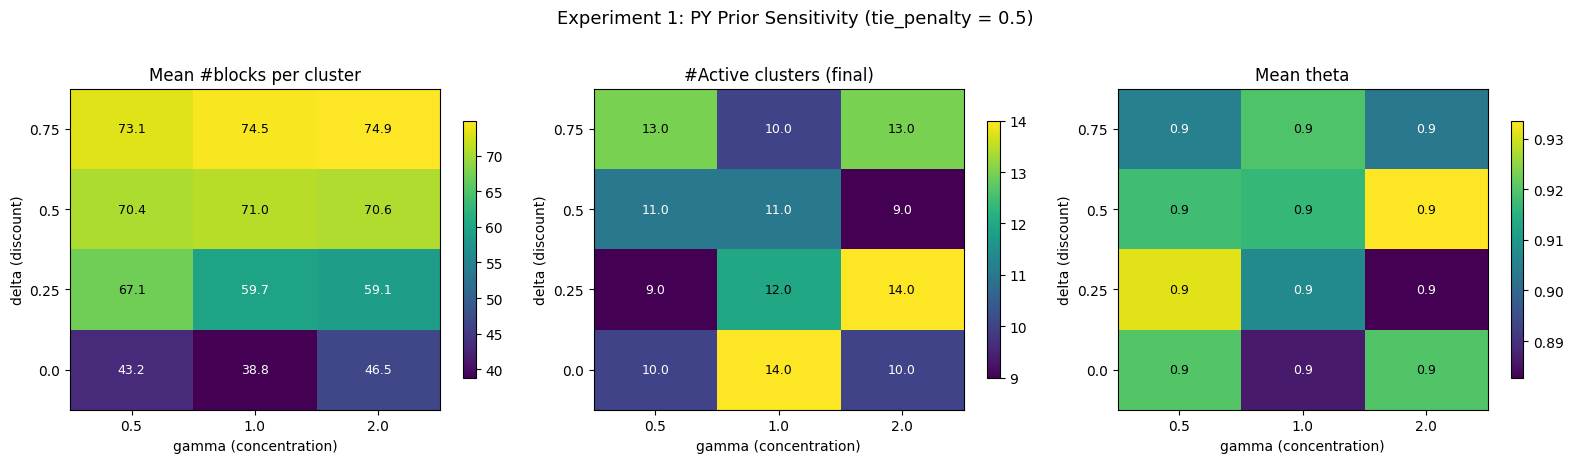

In [16]:
# ── Heatmap: mean K vs (gamma, delta) ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric, title in zip(axes,
    ["K_mean", "n_active_final", "theta_mean"],
    ["Mean #blocks per cluster", "#Active clusters (final)", "Mean theta"]):

    pivot = df1.pivot_table(index="delta", columns="gamma", values=metric)
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto",
                   origin="lower")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("gamma (concentration)")
    ax.set_ylabel("delta (discount)")
    ax.set_title(title)
    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    color="white" if val < pivot.values.mean() else "black",
                    fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Experiment 1: PY Prior Sensitivity (tie_penalty = 0.5)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

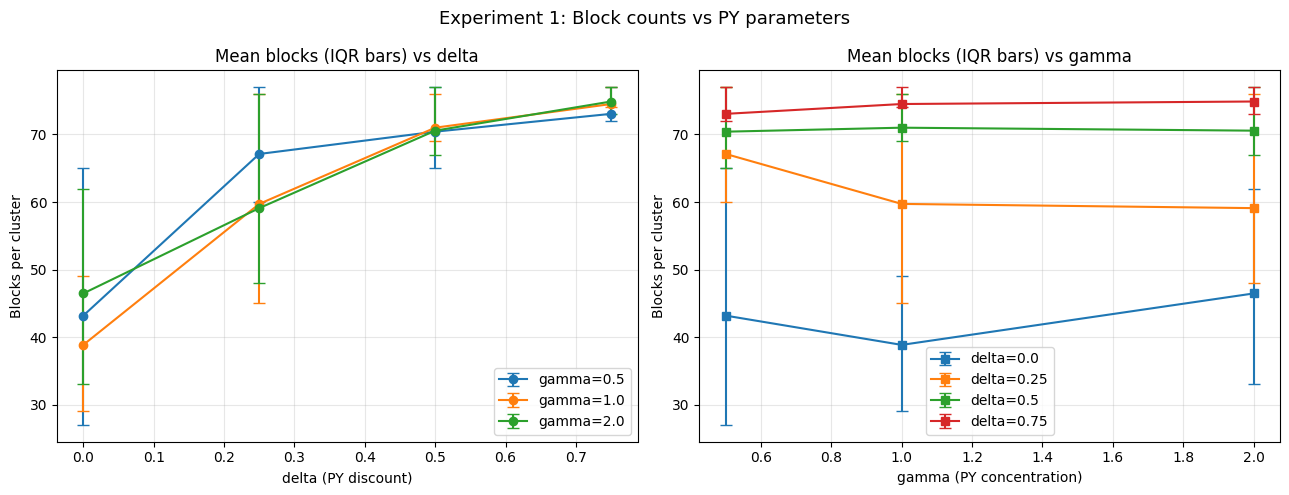

In [17]:
# ── Effect of delta (discount) on block count distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: K_mean vs delta, grouped by gamma
ax = axes[0]
for g, grp in df1.groupby("gamma"):
    grp_s = grp.sort_values("delta")
    ax.errorbar(grp_s["delta"], grp_s["K_mean"],
                yerr=[grp_s["K_mean"] - grp_s["K_q25"],
                      grp_s["K_q75"] - grp_s["K_mean"]],
                marker="o", capsize=4, label=f"gamma={g}")
ax.set_xlabel("delta (PY discount)")
ax.set_ylabel("Blocks per cluster")
ax.set_title("Mean blocks (IQR bars) vs delta")
ax.legend()
ax.grid(alpha=0.3)

# Right: K_mean vs gamma, grouped by delta
ax = axes[1]
for d, grp in df1.groupby("delta"):
    grp_s = grp.sort_values("gamma")
    ax.errorbar(grp_s["gamma"], grp_s["K_mean"],
                yerr=[grp_s["K_mean"] - grp_s["K_q25"],
                      grp_s["K_q75"] - grp_s["K_mean"]],
                marker="s", capsize=4, label=f"delta={d}")
ax.set_xlabel("gamma (PY concentration)")
ax.set_ylabel("Blocks per cluster")
ax.set_title("Mean blocks (IQR bars) vs gamma")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Experiment 1: Block counts vs PY parameters", fontsize=13)
plt.tight_layout()
plt.show()

## Experiment 2: Tie-Penalty Sweep (no PY prior)

In [18]:
# ── Filter to Experiment 2 (no PY prior, varying p) ──────────────────────────
df2 = df[df["use_py_prior"] == False].copy().sort_values("tie_penalty")

print("Experiment 2: Tie-penalty sweep (no PY prior)")
print("=" * 80)
cols2 = ["tie_penalty", "n_active_final", "K_mean", "K_median", "K_std",
         "K_min", "K_max", "K_q25", "K_q75", "theta_mean", "mean_logp"]
display(df2[cols2].round(2))

Experiment 2: Tie-penalty sweep (no PY prior)


,tie_penalty,n_active_final,K_mean,K_median,K_std,K_min,K_max,K_q25,K_q75,theta_mean,mean_logp
0,0.1,14,31.01,29.0,6.28,18,51,26.0,35.0,0.90,NaN
1,0.2,12,36.72,37.5,8.53,18,59,29.0,44.0,0.91,NaN
2,0.3,12,41.21,38.0,11.89,21,76,32.0,49.0,0.91,NaN
3,0.4,13,43.24,38.0,14.66,20,77,32.0,50.0,0.90,NaN
4,0.5,10,52.35,47.0,16.42,27,77,37.0,70.0,0.92,NaN
5,0.6,11,49.63,44.0,18.33,18,77,35.0,72.0,0.91,NaN
6,0.7,12,47.63,42.0,15.98,24,77,35.0,57.0,0.91,NaN
7,0.8,11,55.94,51.0,14.59,27,77,44.0,72.0,0.91,NaN
8,0.9,13,52.89,46.0,16.91,26,77,39.0,76.0,0.90,NaN


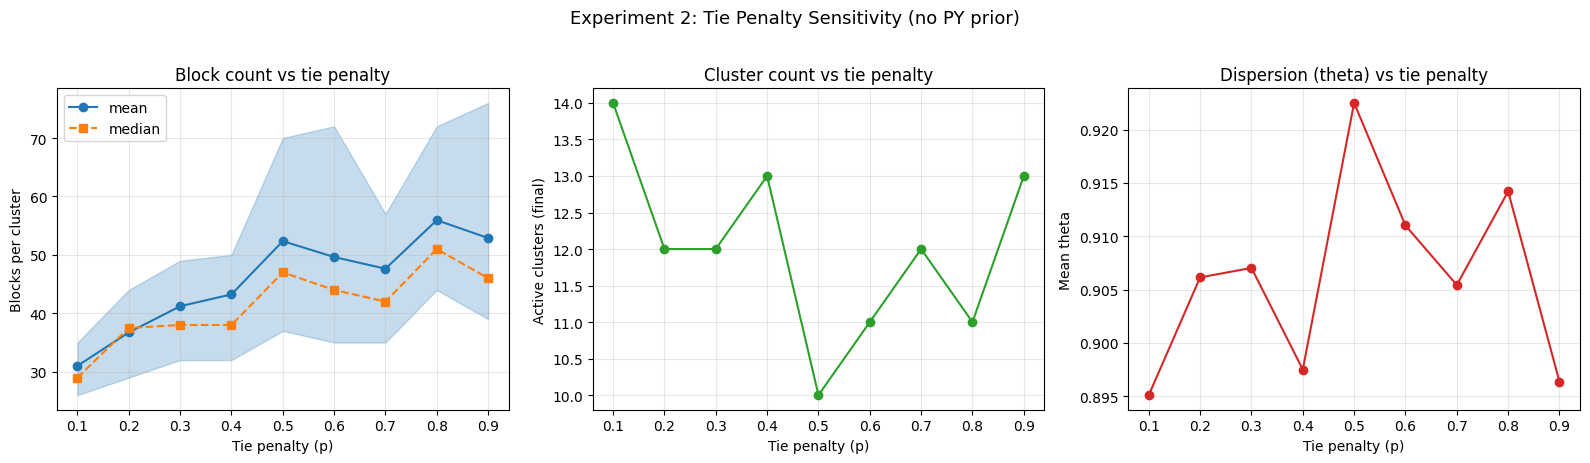

In [19]:
# ── Tie-penalty effect on block structure ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Blocks vs p
ax = axes[0]
ax.fill_between(df2["tie_penalty"], df2["K_q25"], df2["K_q75"], alpha=0.25, color="C0")
ax.plot(df2["tie_penalty"], df2["K_mean"], "o-", color="C0", label="mean")
ax.plot(df2["tie_penalty"], df2["K_median"], "s--", color="C1", label="median")
ax.set_xlabel("Tie penalty (p)")
ax.set_ylabel("Blocks per cluster")
ax.set_title("Block count vs tie penalty")
ax.legend()
ax.grid(alpha=0.3)

# 2. Active clusters vs p
ax = axes[1]
ax.plot(df2["tie_penalty"], df2["n_active_final"], "o-", color="C2")
ax.set_xlabel("Tie penalty (p)")
ax.set_ylabel("Active clusters (final)")
ax.set_title("Cluster count vs tie penalty")
ax.grid(alpha=0.3)

# 3. Theta vs p
ax = axes[2]
ax.plot(df2["tie_penalty"], df2["theta_mean"], "o-", color="C3")
ax.set_xlabel("Tie penalty (p)")
ax.set_ylabel("Mean theta")
ax.set_title("Dispersion (theta) vs tie penalty")
ax.grid(alpha=0.3)

fig.suptitle("Experiment 2: Tie Penalty Sensitivity (no PY prior)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Block-Count Distribution Comparison

C:\Users\jonanord\AppData\Local\Temp\ipykernel_22620\3391753412.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bdf1_grouped, labels=order1, patch_artist=True)


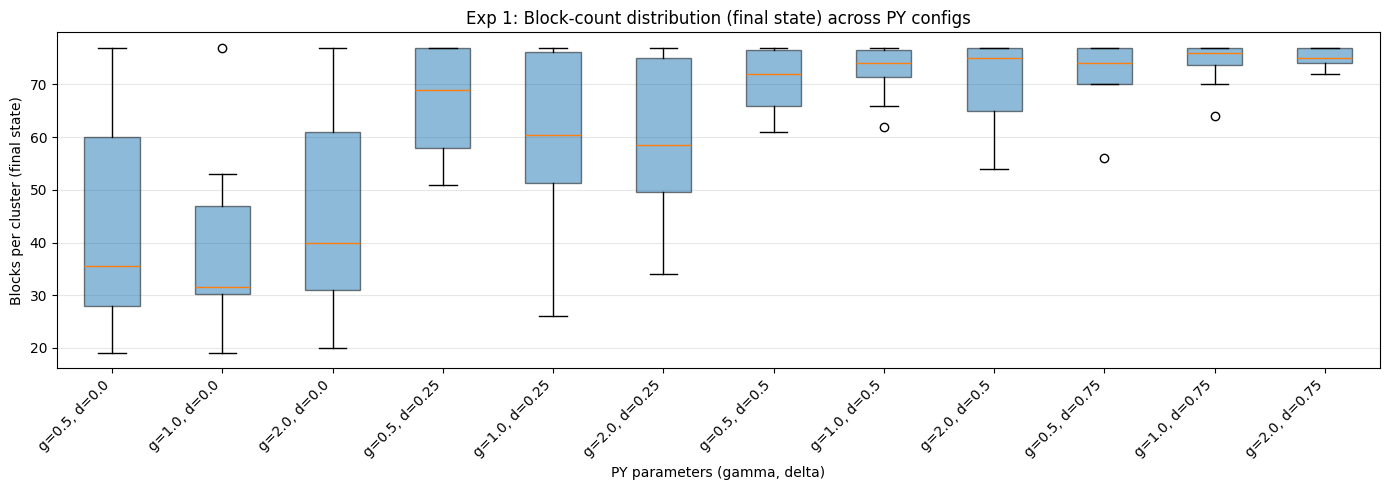

C:\Users\jonanord\AppData\Local\Temp\ipykernel_22620\3391753412.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bdf2_grouped, labels=order2, patch_artist=True)


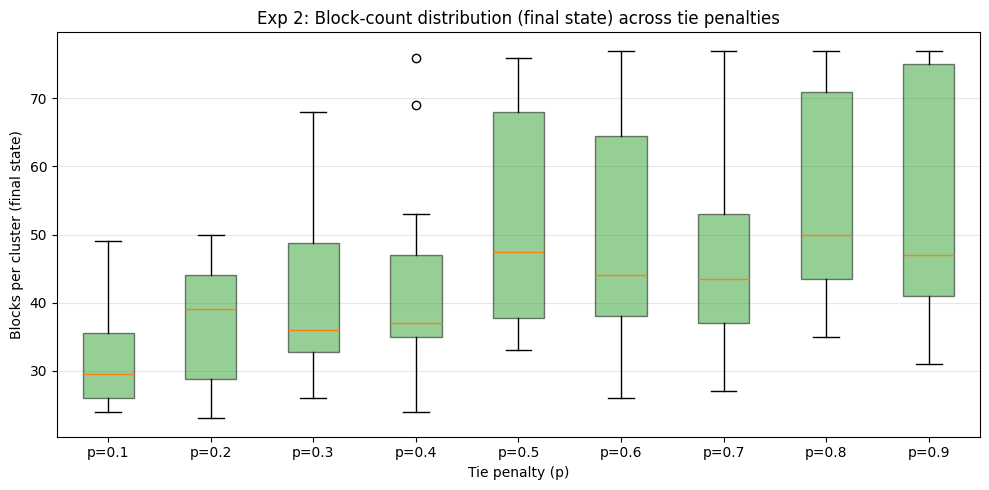

In [20]:
# ── Box-plot comparison: block counts across all configs ─────────────────────
# Reload block counts per active cluster (final state) for each config
box_data = []

for d in config_dirs:
    with open(d / "summary.json") as f:
        s = json.load(f)
    # block_counts: {cluster_id: n_blocks}
    bc = s.get("block_counts", {})
    for cid, nblk in bc.items():
        box_data.append({
            "label": s["label"],
            "gamma": s["gamma"],
            "delta": s["delta"],
            "tie_penalty": s["tie_penalty"],
            "use_py_prior": s["use_py_prior"],
            "n_blocks": nblk,
        })

bdf = pd.DataFrame(box_data)

# ── Exp 1: PY sweep ──────────────────────────────────────────────────────────
bdf1 = bdf[bdf["use_py_prior"] == True].copy()
bdf1["config"] = bdf1.apply(lambda r: f"g={r['gamma']}, d={r['delta']}", axis=1)
# Sort by (delta, gamma)
order1 = bdf1.drop_duplicates("config").sort_values(["delta", "gamma"])["config"].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
bdf1_grouped = [bdf1[bdf1["config"] == cfg]["n_blocks"].values for cfg in order1]
bp = ax.boxplot(bdf1_grouped, labels=order1, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("C0")
    patch.set_alpha(0.5)
ax.set_ylabel("Blocks per cluster (final state)")
ax.set_xlabel("PY parameters (gamma, delta)")
ax.set_title("Exp 1: Block-count distribution (final state) across PY configs")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Exp 2: tie-penalty sweep ─────────────────────────────────────────────────
bdf2 = bdf[bdf["use_py_prior"] == False].copy()
if len(bdf2) > 0:
    bdf2["config"] = bdf2["tie_penalty"].apply(lambda p: f"p={p:.1f}")
    order2 = bdf2.drop_duplicates("config").sort_values("tie_penalty")["config"].tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    bdf2_grouped = [bdf2[bdf2["config"] == cfg]["n_blocks"].values for cfg in order2]
    bp = ax.boxplot(bdf2_grouped, labels=order2, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("C2")
        patch.set_alpha(0.5)
    ax.set_ylabel("Blocks per cluster (final state)")
    ax.set_xlabel("Tie penalty (p)")
    ax.set_title("Exp 2: Block-count distribution (final state) across tie penalties")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No Exp 2 configs found yet.")

## Block-Count Traces Over MCMC Iterations

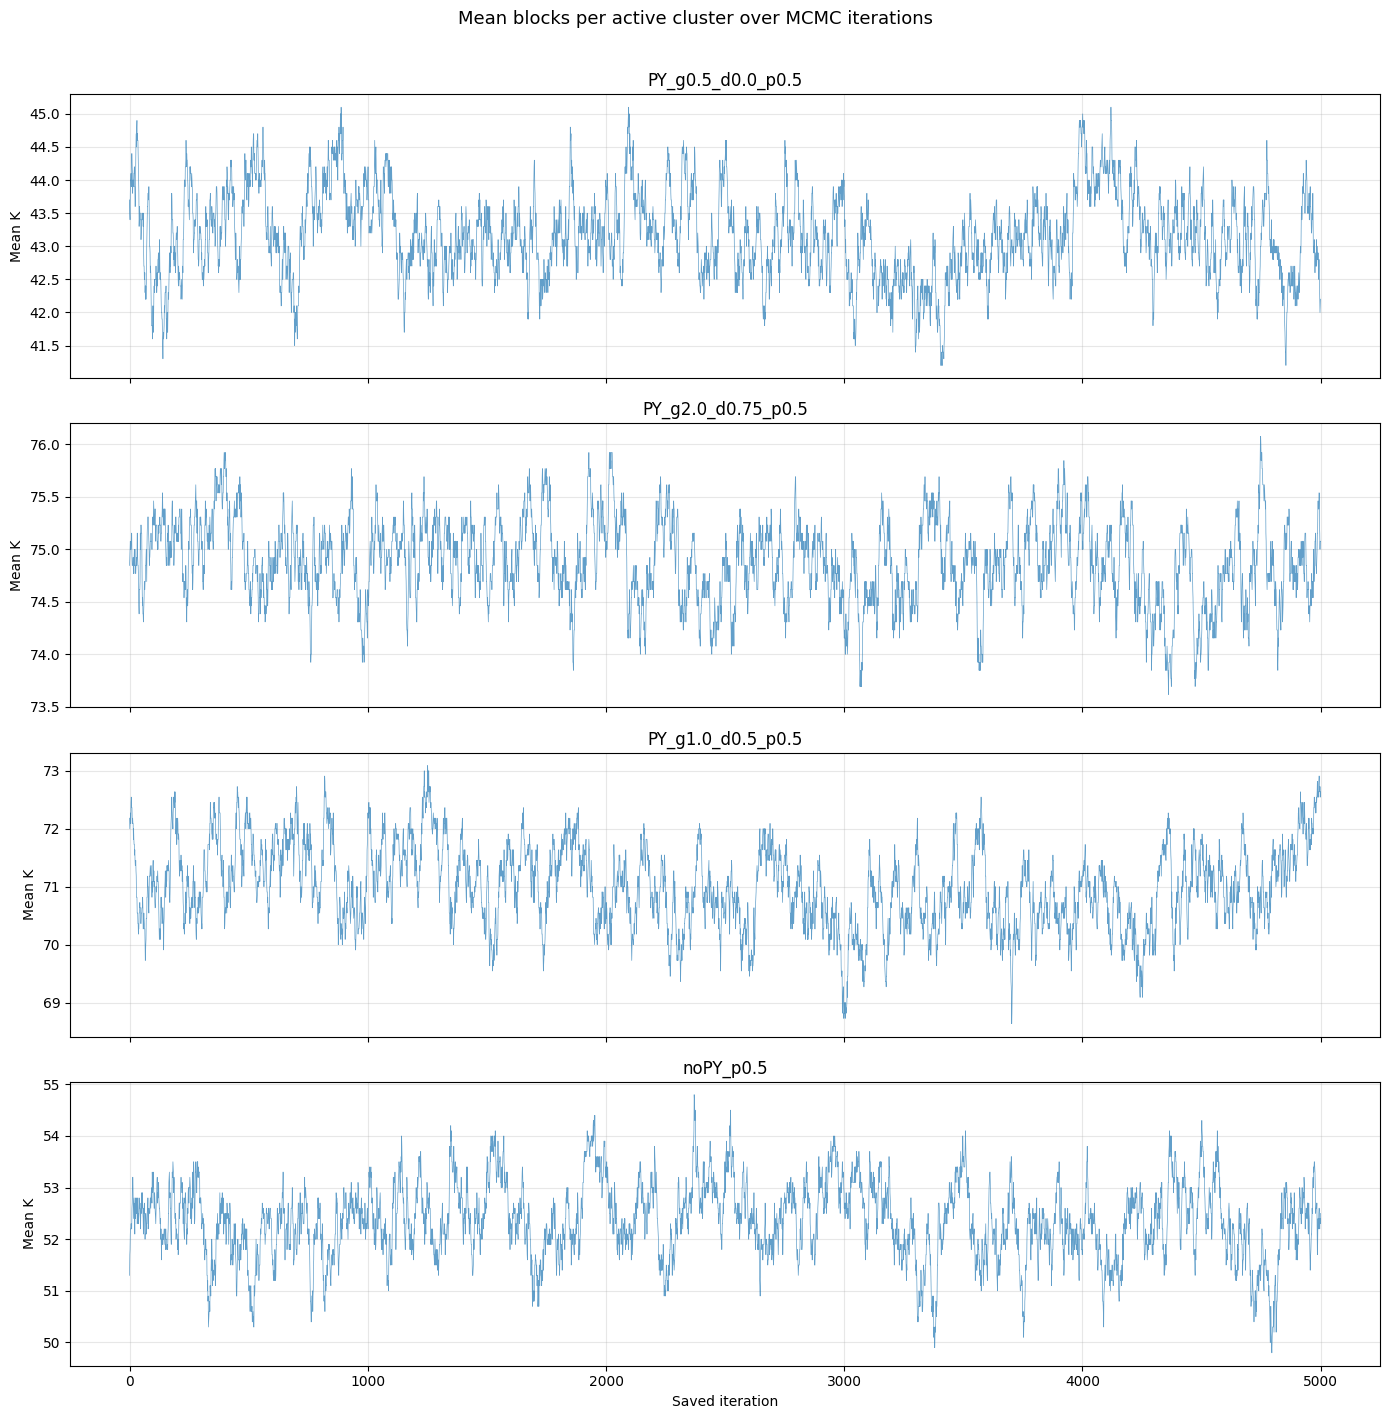

In [21]:
# ── K trace for a few representative configs ─────────────────────────────────
# Pick 4 configs: corners of the PY grid + one tie-penalty
trace_labels = []
for lbl in ["PY_g0.5_d0.0_p0.5", "PY_g2.0_d0.75_p0.5",
            "PY_g1.0_d0.5_p0.5", "noPY_p0.5"]:
    d = SENS_DIR / lbl
    if (d / "samples.pkl").exists():
        trace_labels.append(lbl)

if trace_labels:
    fig, axes = plt.subplots(len(trace_labels), 1,
                             figsize=(14, 3.5 * len(trace_labels)), sharex=True)
    if len(trace_labels) == 1:
        axes = [axes]

    for ax, lbl in zip(axes, trace_labels):
        with open(SENS_DIR / lbl / "samples.pkl", "rb") as f:
            samp = pickle.load(f)
        K_arr = np.array(samp.K)
        z_arr = np.array(samp.z_samples)
        T_s = K_arr.shape[0]

        # Compute mean K over active clusters per iteration
        mean_k = []
        for t in range(T_s):
            active = set(z_arr[t])
            k_act = [K_arr[t, c] for c in active if K_arr[t, c] > 0]
            mean_k.append(np.mean(k_act) if k_act else np.nan)

        ax.plot(mean_k, linewidth=0.5, alpha=0.7)
        ax.set_ylabel("Mean K")
        ax.set_title(lbl)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Saved iteration")
    fig.suptitle("Mean blocks per active cluster over MCMC iterations", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No trace configs found yet — run the sensitivity analysis first.")

## Summary Table (LaTeX-ready)

In [22]:
# ── Combined summary table ────────────────────────────────────────────────────
summary_cols = ["label", "gamma", "delta", "tie_penalty", "use_py_prior",
                "n_active_final", "K_mean", "K_median", "K_std",
                "K_min", "K_max", "K_q25", "K_q75",
                "theta_mean", "mean_logp", "elapsed_s"]

summary = df[summary_cols].round(2)
print(summary.to_string(index=False))

# Save to CSV
out_csv = SENS_DIR / "analysis_summary.csv"
summary.to_csv(out_csv, index=False)
print(f"\nSaved to {out_csv}")

             label  gamma  delta  tie_penalty  use_py_prior  n_active_final  K_mean  K_median  K_std  K_min  K_max  K_q25  K_q75  theta_mean  mean_logp  elapsed_s
         noPY_p0.1    1.0   0.50          0.1         False              14   31.01      29.0   6.28     18     51   26.0   35.0        0.90        NaN      523.8
         noPY_p0.2    1.0   0.50          0.2         False              12   36.72      37.5   8.53     18     59   29.0   44.0        0.91        NaN      962.7
         noPY_p0.3    1.0   0.50          0.3         False              12   41.21      38.0  11.89     21     76   32.0   49.0        0.91        NaN      546.8
         noPY_p0.4    1.0   0.50          0.4         False              13   43.24      38.0  14.66     20     77   32.0   50.0        0.90        NaN      573.5
         noPY_p0.5    1.0   0.50          0.5         False              10   52.35      47.0  16.42     27     77   37.0   70.0        0.92        NaN     1245.3
         noPY_p0.6    